In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set tthe file path
FILE_PATH = Path("cleaned_dataset_lianafarsi.xlsx")

# Load the dataset
df = pd.read_excel(FILE_PATH)

In [ ]:
required_columns = [
    "customer_id", "first_name", "gender", "age", "city", "province",
    "signup_date", "membership_tier", "purchase_count", "avg_order_value",
    "total_spending", "last_purchase_days", "payment_method", "device",
    "discount_used", "returned_items", "satisfaction_score"
     ]

# check for missing columns
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
  raise ValueError(f"Missing columns: {missing_columns}")

In [ ]:
# Convert date to standard datetime format
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Convert numeric columns
numeric_columns = ['age', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

for col in numeric_columns:
  df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean text columns
text_columns = ["first_name", "gender", "city", "province", "membership_tier",
    "payment_method", "device", "discount_used"]

for col in text_columns:
  df[col] = df[col].astype("string").str.strip()

In [ ]:
# Display data quality metrixcs
print(f"Dataset dimentions: {df.shape}")
print(f"Duplicate records: {df.duplicated().sum()}")
print(f"Missing values per columns:")
print(df.isna().sum().sort_values(ascending=False))

display(df.head())


Dataset dimentions: (60, 18)
Duplicate records: 0
Missing values per columns:
customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
data_quality_issue    0
dtype: int64


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,data_quality_issue
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,No
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,No
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,No
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,No
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,No


In [ ]:
# Drop rows with missing values in key columns for this specific analysis
analysis_df = df.dropna(
    subset=["gender", "age", "membership_tier", "device", "payment_method"]
).copy()

# Define age bins and labels for Customer Segmentation
age_bins = [0, 24, 34, 44, 54, 64, np.inf]
age_labels = ["Under 25", "25-34", "35-44", "45-54", "55-64", "64+"]

analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Customer Profiling & Summary Statistics
profile_summary = {
    "Total_Customers": analysis_df["customer_id"].nunique(),
    "Average_Age": analysis_df["age"].mean(),
    "Median_Age": analysis_df["age"].median(),
    "Most_Common_Gender": analysis_df["gender"].mode().iloc[0],
    "Most_Common_Membership": analysis_df["membership_tier"].mode().iloc[0],
    "Most_Common_Device": analysis_df["device"].mode().iloc[0],
    "Most_Common_Payment": analysis_df["payment_method"].mode().iloc[0]
}

profile_table = pd.Series(profile_summary, name="Value")
display(profile_table)

,Value
Total_Customers,60
Average_Age,43.7
Median_Age,45.0
Most_Common_Gender,F
Most_Common_Membership,Gold
Most_Common_Device,Android
Most_Common_Payment,Online Wallet


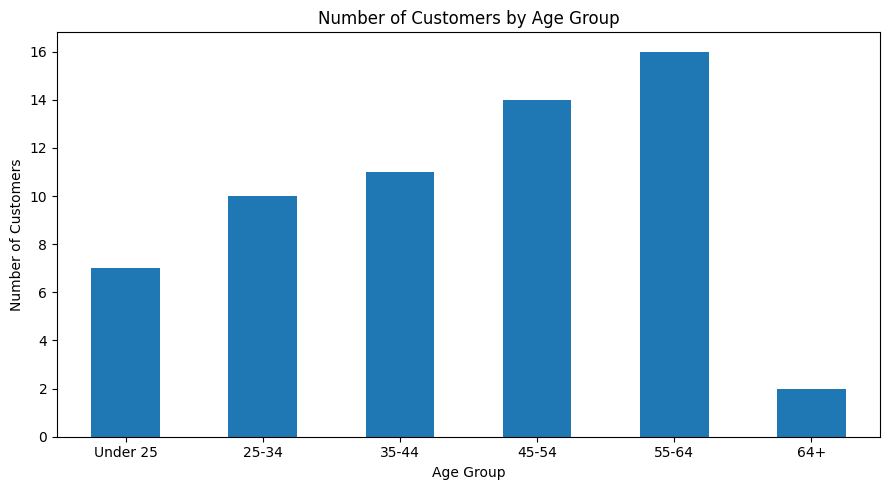

In [ ]:
# Data Visualization - Age Distribution
age_counts = analysis_df["age_group"].value_counts(sort=False)
age_counts.plot(kind="bar", figsize=(9, 5))

plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Aggregating City Data
location_df = df.dropna(
    subset=["province", "city", "customer_id", "total_spending", "satisfaction_score"]
).copy()

city_summary = (
    location_df.groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

# Filter out cities with very few customers (<3) to ensure stable and reliable metrics
city_summary = city_summary[city_summary["customer_count"] >= 3].copy()

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


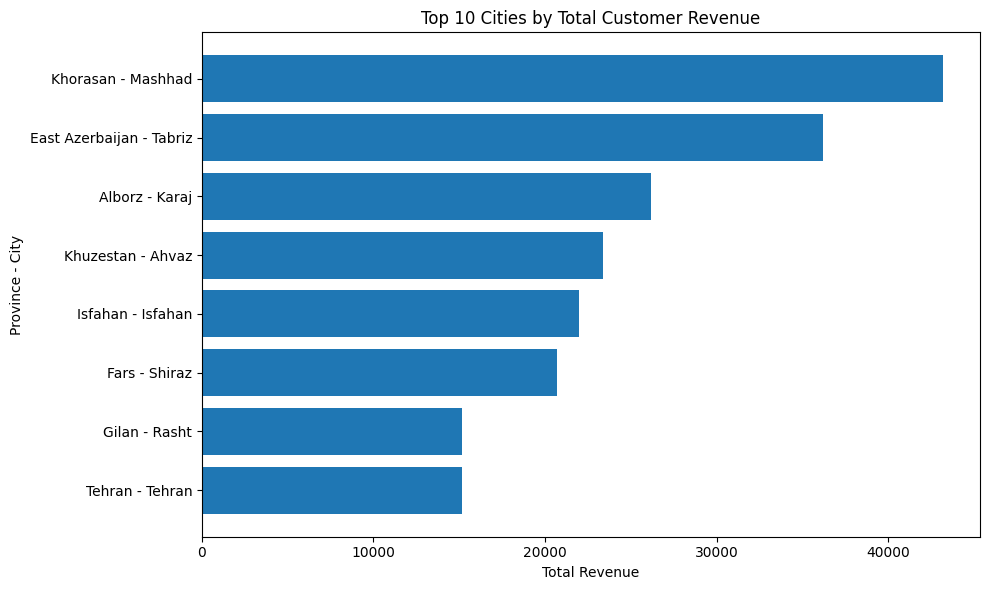

In [ ]:
# Top 10 cities by revenue
top_cities = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
display(top_cities.sort_values("total_revenue", ascending=False))

labels = top_cities["province"] + " - " + top_cities["city"]

plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities["total_revenue"])
plt.title("Top 10 Cities by Total Customer Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Province - City")
plt.tight_layout()
plt.show()

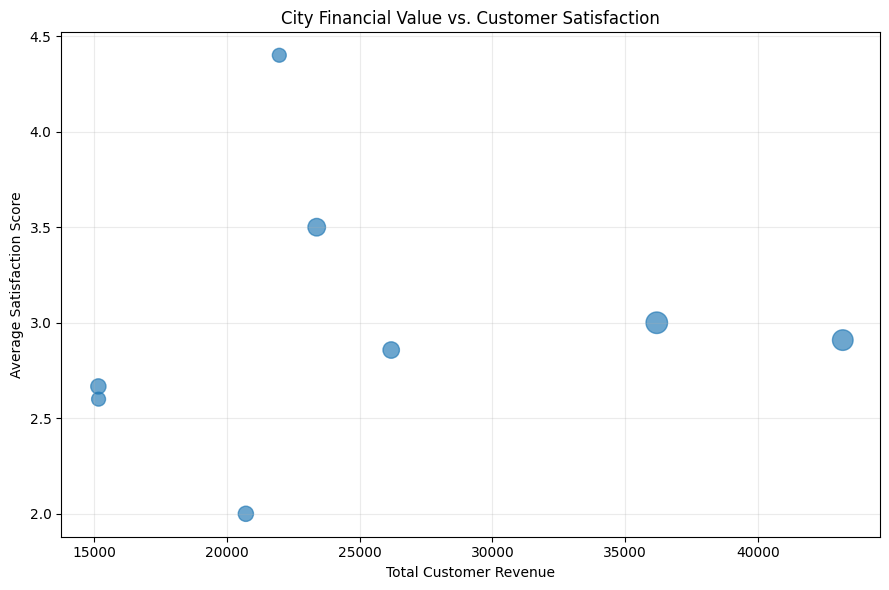

In [ ]:
# Scatter plot  - Financial Value vs. Satisfaction
plt.figure(figsize=(9, 6))
plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65
)

plt.title("City Financial Value vs. Customer Satisfaction")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Average Satisfaction Score")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Recomended City
recommended_city = city_summary.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
    ).head(1)

print("Recommended City for Advertising Campaign:")
display(recommended_city)

Recommended City for Advertising Campaign:


,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091


In [ ]:
# Data Prepration and Min-Max Normalization
loyalty_df = df.dropna(
    subset=["customer_id", "first_name", "purchase_count", "total_spending",
        "last_purchase_days", "satisfaction_score"]

).copy()

# Normalize spending, frequency, and satisfaction (Higher is better)
for column in ["purchase_count", "total_spending", "satisfaction_score"]:
    minimum = loyalty_df[column].min()
    maximum = loyalty_df[column].max()

    if maximum == minimum:
        loyalty_df[f"{column}_score"] = 1.0
    else:
        loyalty_df[f"{column}_score"] = (loyalty_df[column] - minimum) / (maximum - minimum)

# Normalize recency (Lower days = Higher score)
recency_min = loyalty_df["last_purchase_days"].min()
recency_max = loyalty_df["last_purchase_days"].max()

if recency_max == recency_min:
    loyalty_df["recency_score"] = 1.0
else:
    loyalty_df["recency_score"] = 1 - ((loyalty_df["last_purchase_days"] - recency_min) / (recency_max - recency_min))

In [ ]:
# Calculate Weighted Loyalty Score and Select Top 10
loyalty_df["loyalty_score"] = (
    0.35 * loyalty_df["total_spending_score"] +
    0.30 * loyalty_df["purchase_count_score"] +
    0.20 * loyalty_df["recency_score"] +
    0.15 * loyalty_df["satisfaction_score_score"]
)

# Extract the top 10 customers based on the calculated score
top_loyal_customers = loyalty_df.nlargest(10, "loyalty_score")[[
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score", "loyalty_score"
]]

display(top_loyal_customers)

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.864535
43,1044,Mina,Gold,33,14354.34,165,2,0.780854
58,1059,Ali,Gold,31,8898.55,224,5,0.710587
8,1009,Kimia,Silver,34,11615.42,232,2,0.685627
3,1004,Sina,Gold,23,6121.45,40,4,0.638459
11,1012,Arash,Gold,27,11731.50,224,2,0.632877
32,1033,Neda,VIP,24,5521.20,112,5,0.630116
13,1014,Reza,VIP,31,3353.89,97,4,0.608058
22,1023,Ali,Bronze,31,3851.44,170,4,0.579858
16,1017,Parsa,VIP,30,3239.40,135,4,0.575701


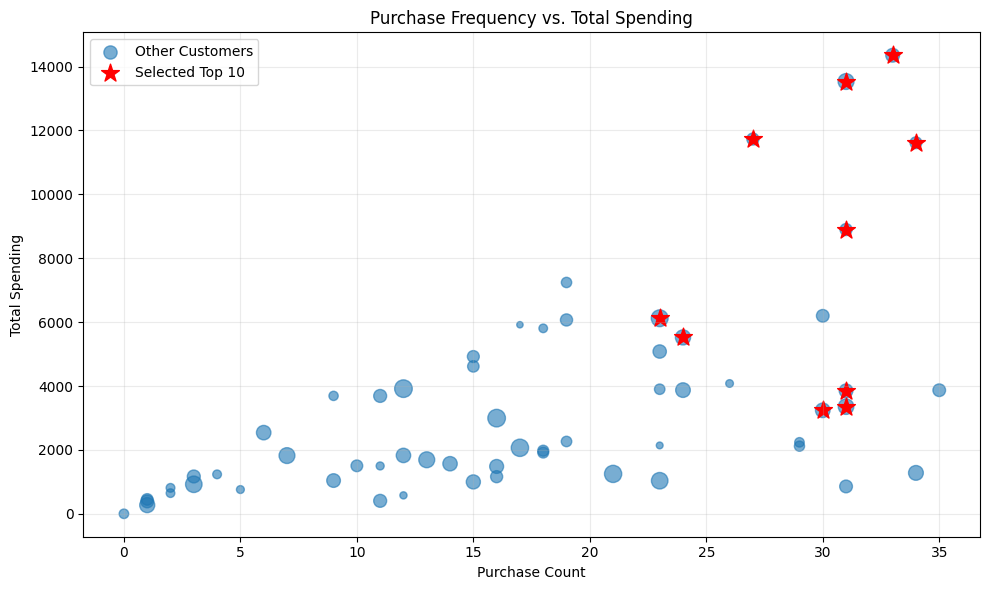

In [ ]:
# Visualization of Loyal Customers
plt.figure(figsize=(10, 6))

# Plot all customers
plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    alpha=0.6,
    label="Other Customers"
)

# Highlight the selected top 10 customers
plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=180,
    marker="*",
    color="red",
    label="Selected Top 10"
)

plt.title("Purchase Frequency vs. Total Spending")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Define At-Risk Thresholds
risk_df = df.dropna(
    subset=["customer_id", "first_name", "total_spending", "purchase_count", "last_purchase_days"]
).copy()

# Define thresholds using statistical percentiles
spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

# Flag customers who meet ALL three conditions
risk_df["at_risk"] = (
    (risk_df["total_spending"] >= spending_threshold) &
    (risk_df["purchase_count"] >= purchase_threshold) &
    (risk_df["last_purchase_days"] >= inactivity_threshold)
)

In [ ]:
# Extract Target Customers for Win-Back Campaign
at_risk_customers = risk_df.loc[risk_df["at_risk"], [
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score"
]].sort_values(
    ["total_spending", "last_purchase_days"],
    ascending=[False, False]
)

print(f"Number of At-Risk Customers: {len(at_risk_customers)}")
display(at_risk_customers)

Number of At-Risk Customers: 3


,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


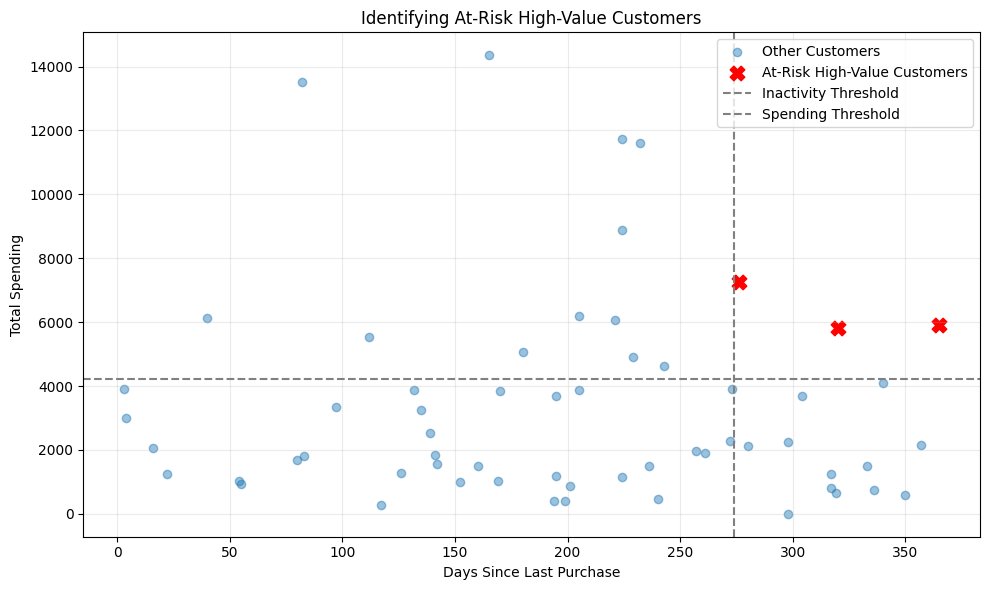

In [ ]:
# Visualization of At-Risk Customers
plt.figure(figsize=(10, 6))

# Plot safe customers
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.45,
    label="Other Customers"
)

# Plot at-risk customers (Top Right Quadrant)
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=110,
    color="red",
    label="At-Risk High-Value Customers"
)

# Add threshold lines to define the risk zone
plt.axvline(inactivity_threshold, linestyle="--", color="gray", label="Inactivity Threshold")
plt.axhline(spending_threshold, linestyle="--", color="gray", label="Spending Threshold")

plt.title("Identifying At-Risk High-Value Customers")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

--- Summary by Discount Usage ---


,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3736.741176,17.294118,220.700588,4.264706,2.764706
1,Yes,26,2882.174231,17.500000,203.291154,4.076923,3.269231


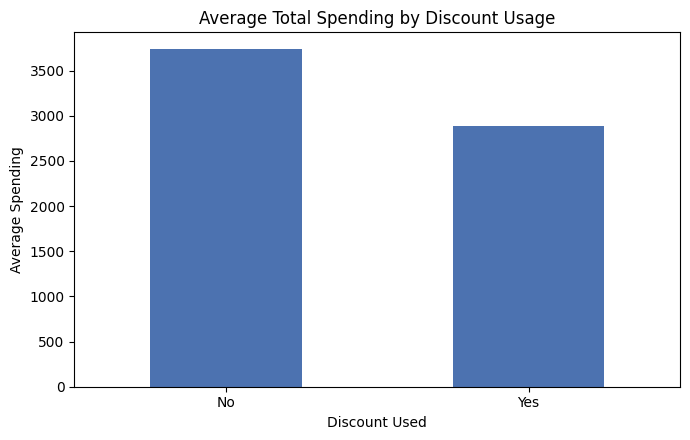

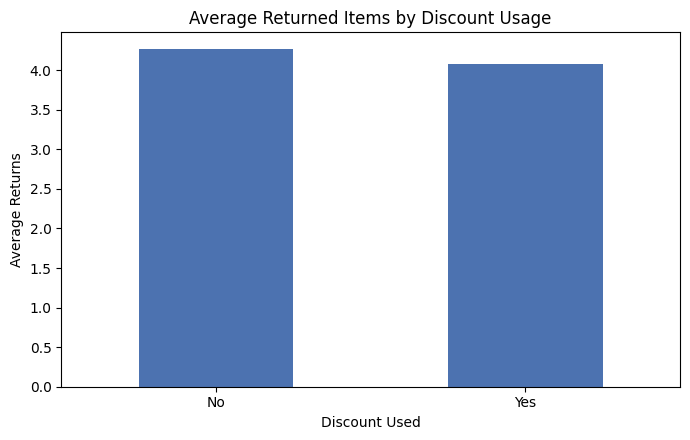

In [ ]:
# Impact of Discounts on Spending and Returns
factor_df = df.dropna(
    subset=[
        "discount_used", "device", "payment_method", "total_spending",
        "purchase_count", "avg_order_value", "returned_items",
        "satisfaction_score"
    ]
).copy()

# Aggregate metrics by discount usage (Descriptive comparison)
summary_by_discount = (
    factor_df.groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

print("--- Summary by Discount Usage ---")
display(summary_by_discount)

# Plot Discount comparisons using a loop
metrics = [
    ("avg_total_spending", "Average Total Spending by Discount Usage", "Average Spending"),
    ("avg_returned_items", "Average Returned Items by Discount Usage", "Average Returns")
]

for metric, title, ylabel in metrics:
    summary_by_discount.plot(
        x="discount_used", y=metric, kind="bar", legend=False, figsize=(7, 4.5), color="#4C72B0"
    )
    plt.title(title)
    plt.xlabel("Discount Used")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


--- Summary by Device ---


,count,mean
device,,
Web,20,2897.760000
Android,22,3459.069091
iPhone,18,3773.945000


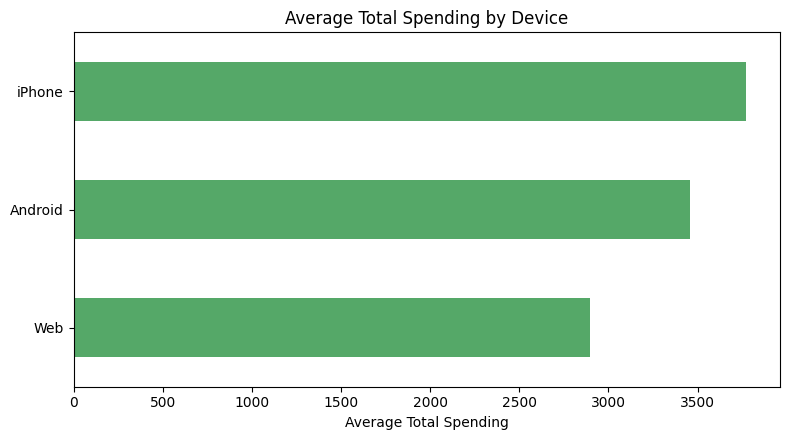


--- Summary by Payment Method ---


,count,mean
payment_method,,
Online Wallet,23,3104.462174
Cash,19,3150.579474
Card,18,3929.005000


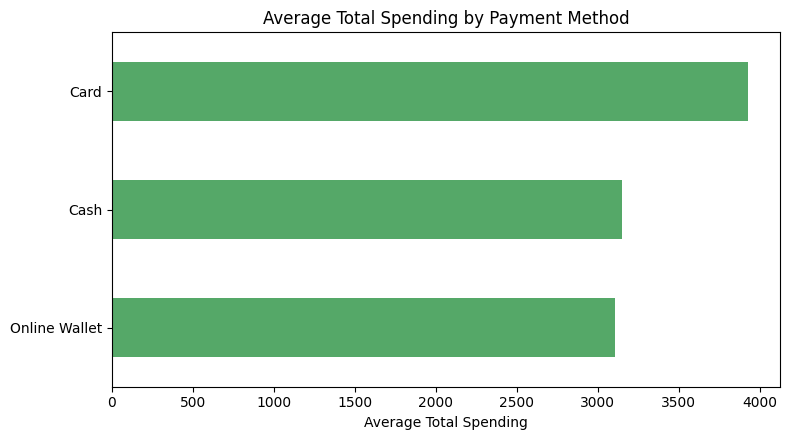

In [ ]:
# Impact of Device and Payment Method on Spending
for factor, title in [
    ("device", "Average Total Spending by Device"),
    ("payment_method", "Average Total Spending by Payment Method")
]:
    # Group by factor, calculate count and mean, filter low samples, and sort
    factor_summary = (
        factor_df.groupby(factor)["total_spending"]
        .agg(["count", "mean"])
        .query("count >= 3")
        .sort_values("mean", ascending=True)
    )

    print(f"\n--- Summary by {factor.replace('_', ' ').title()} ---")
    display(factor_summary)

    # Plot horizontal bar charts for better readability
    factor_summary["mean"].plot(kind="barh", figsize=(8, 4.5), color="#55A868")
    plt.title(title)
    plt.xlabel("Average Total Spending")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [ ]:
# Calculate Global KPIs for the CEO Dashboard
kpi_summary = pd.Series({
    "Total Unique Customers": df["customer_id"].nunique(),
    "Total Revenue": df["total_spending"].sum(),
    "Avg Spending per Customer": df["total_spending"].mean(),
    "Avg Purchase Count": df["purchase_count"].mean(),
    "Avg Satisfaction Score": df["satisfaction_score"].mean(),
    "Total Returned Items": df["returned_items"].sum()
}, name="Value")

print("--- Global KPIs ---")
display(kpi_summary)

--- Global KPIs ---


,Value
Total Unique Customers,60.000000
Total Revenue,201985.730000
Avg Spending per Customer,3366.428833
Avg Purchase Count,17.383333
Avg Satisfaction Score,2.983333
Total Returned Items,251.000000


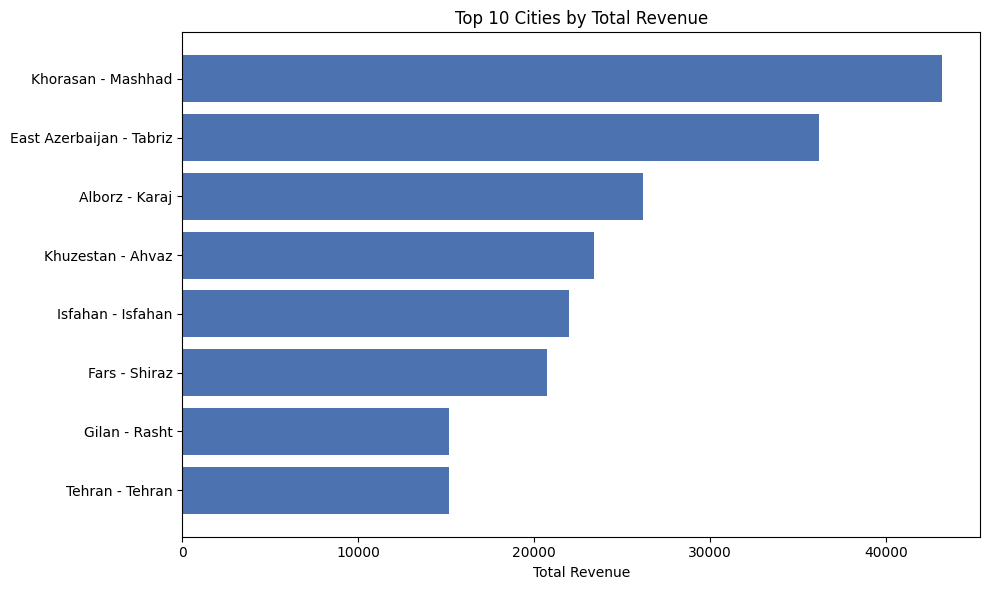

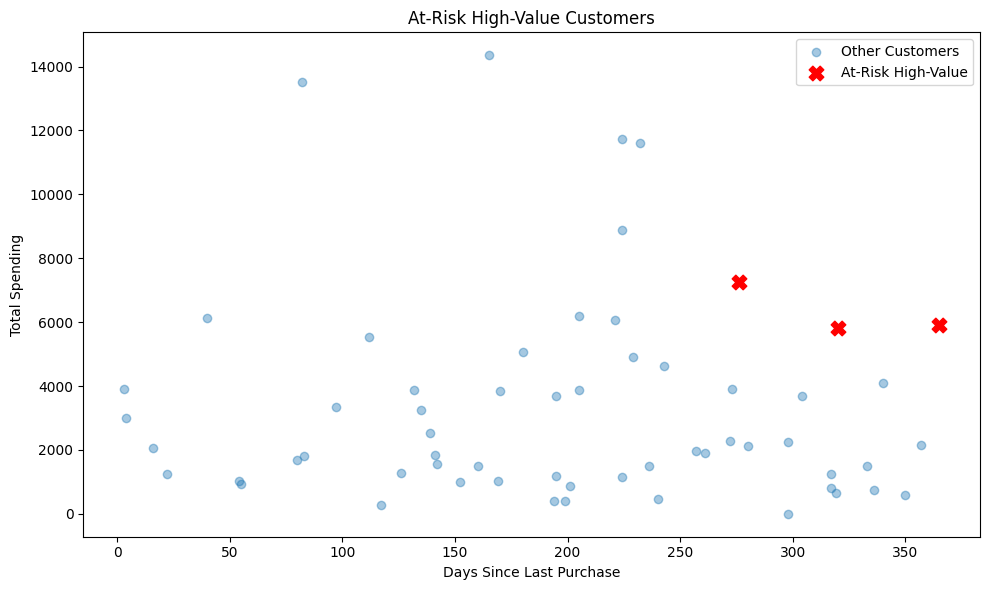

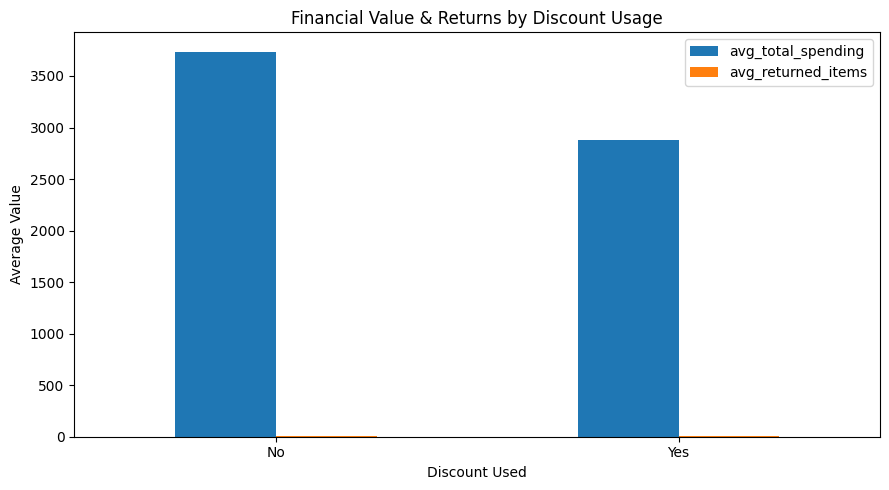

In [ ]:
# Generate the 3 Final Charts for the 5-Minute Report

# Chart 1: Top 10 Cities
chart1 = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
chart1_labels = chart1["province"] + " - " + chart1["city"]

plt.figure(figsize=(10, 6))
plt.barh(chart1_labels, chart1["total_revenue"], color="#4C72B0")
plt.title("Top 10 Cities by Total Revenue")
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.show()

# Chart 2: At-Risk High-Value Customers
plt.figure(figsize=(10, 6))
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.4, label="Other Customers"
)
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X", s=110, color="red", label="At-Risk High-Value"
)
plt.title("At-Risk High-Value Customers")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.show()

# Chart 3: Discount Impact
summary_by_discount.plot(
    x="discount_used",
    y=["avg_total_spending", "avg_returned_items"],
    kind="bar",
    figsize=(9, 5)
)
plt.title("Financial Value & Returns by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Export Final Results to Excel
with pd.ExcelWriter("customer_analytics_results.xlsx") as writer:
    kpi_summary.to_excel(writer, sheet_name="KPIs")
    city_summary.to_excel(writer, sheet_name="City Analysis", index=False)
    top_loyal_customers.to_excel(writer, sheet_name="Top Loyal Customers", index=False)
    at_risk_customers.to_excel(writer, sheet_name="At Risk Customers", index=False)
    summary_by_discount.to_excel(writer, sheet_name="Discount Analysis", index=False)

print("Data successfully exported to 'customer_analytics_results.xlsx'")

Data successfully exported to 'customer_analytics_results.xlsx'
